### Make classification data and get it ready

In [1]:
import sklearn

In [2]:
from sklearn.datasets import make_circles

n_samples = 1000

X, y = make_circles(n_samples=n_samples,
                   noise=0.03,
                   factor=0.2,
                   random_state=42)

In [3]:
len(X), len(y)

(1000, 1000)

In [4]:
# Make DataFrame
import pandas as pd
circles = pd.DataFrame({"X1": X[:, 0],
                      "X2": X[:, 1],
                      "label": y})
circles.head()

,X1,X2,label
0,0.175017,0.074976,1
1,-0.164147,0.055677,1
2,-0.220123,0.098082,1
3,-0.138263,0.149987,1
4,0.442208,-0.896723,0


<Axes: xlabel='X1', ylabel='X2'>

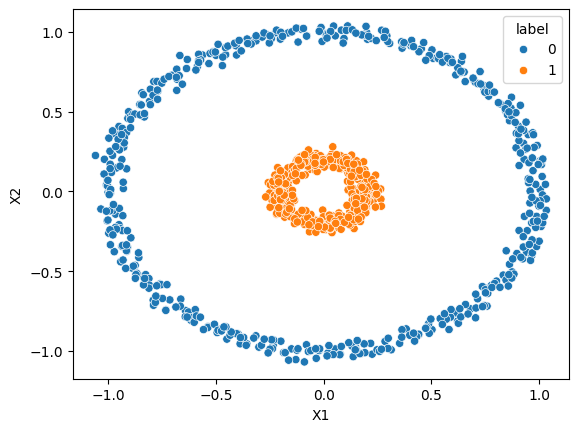

In [5]:
import seaborn as sns
sns.scatterplot(data=circles,
               x="X1",
               y="X2",
               hue="label")


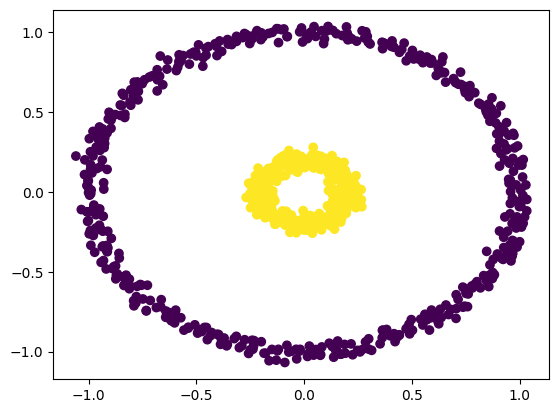

In [6]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0],
           y=X[:, 1],
           c=y)
#

[Datasets](https://scikit-learn.org/stable/datasets)

### Input and output shapes

In [7]:
import torch

In [8]:
# Turn data into tensors
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [9]:
X[:5], y[:5]

(tensor([[ 0.1750,  0.0750],
         [-0.1641,  0.0557],
         [-0.2201,  0.0981],
         [-0.1383,  0.1500],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
type(X) , X.dtype, y.dtype

(torch.Tensor, torch.float32, torch.float32)

In [11]:
# Split data into training and test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

In [12]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

## 2. Building a model

In [13]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
class CircleModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=5)
        self.layer_2 = nn.Linear(in_features=5, out_features=1)

    def forward(self, x):
        return self.layer_2(self.layer_1(x)) # x -> layer_1 -> layer_2 -> output

# Instancieate an instance of outr model class and send it to the target device
model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [15]:
# Replicate the model above using nn.Sequential
model_0 = nn.Sequential(
    nn.Linear(in_features=2, out_features=5),
    nn.Linear(in_features=5, out_features=1)
).to(device)
model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [16]:
# Make predictions
untrained_preds = model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}")
print(f"Shape of predictions: {untrained_preds.shape}")
print(f"Predictions:\n{untrained_preds[:10]}")


Length of predictions: 200
Shape of predictions: torch.Size([200, 1])
Predictions:
tensor([[-0.1415],
        [-0.4819],
        [-0.0401],
        [-0.4550],
        [ 0.0074],
        [-0.0215],
        [-0.3947],
        [-0.2603],
        [-0.0116],
        [-0.4914]], device='cuda:0', grad_fn=<SliceBackward0>)


### Setup loss function and optimizer

In [17]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss()

# Setup optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(),
                           lr=0.1)

In [18]:
# Claculating accuracy
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc
#

### Train model

1. Forward pass
2. Calculate loss
3. Optimizer zero grad
4. Loss backward (backpropagation)
5. Optimizer step (gradient descent)

In [19]:
# View the first five outputs of the forward pass on the test data
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[-0.1415],
        [-0.4819],
        [-0.0401],
        [-0.4550],
        [ 0.0074]], device='cuda:0')

In [20]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [21]:
# Use the sigmoid activation function on our logits to turn them into prediction probabilities
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4647],
        [0.3818],
        [0.4900],
        [0.3882],
        [0.5018]], device='cuda:0')

In [22]:
torch.round(y_pred_probs)

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [1.]], device='cuda:0')

For our prediction probability values, we need to perform a range-style rounding on them:
* `y_pred_probs` >= 0.5, `y=1` (class 1)
* `y_pred_probs` <0.5, `y=0` (class 2)

In [23]:
# Find the predicted labels
y_pred = torch.round(y_pred_probs)

# In full (logits -> pred probs -> pred labels)
y_pred_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_pred.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_pred.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([0., 0., 0., 0., 1.], device='cuda:0')

### Building a training and test loop

In [24]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put dta to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

# Building training and evaluation loop
for epoch in range(epochs):
    model_0.train()

    # 1. Forward pass
    y_logits = model_0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits)) # turn logits -> pred probs -> pred labels

    # Calculate loss/acc
    #loss = loss_fn(torch.sigmoid(y_logits),
    #               y_train)
    loss = loss_fn(y_logits,
                   y_train)
    acc = accuracy_fn(y_true=y_train,
                      y_pred=y_pred)

    # Optimizer 0 grad
    optimizer.zero_grad()

    # Loss backward (backpropagation)
    loss.backward()

    # Optimizer step ( gradient descent)
    optimizer.step()

    ### Testing
    model_0.eval()
    with torch.inference_mode():
      # Forward pass
      test_logits = model_0(X_test).squeeze()
      test_pred = torch.round(torch.sigmoid(test_logits))

      # Calculate test loss/acc
      test_loss = loss_fn(test_logits,
                          y_test)
      test_acc = accuracy_fn(y_true=y_test,
                             y_pred=test_pred)

    # Print
    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:5f}, Acc: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.702492, Acc: 31.13% | Test loss: 0.68922, Test acc: 38.00%
Epoch: 10 | Loss: 0.701161, Acc: 37.00% | Test loss: 0.68867, Test acc: 44.00%
Epoch: 20 | Loss: 0.700161, Acc: 40.12% | Test loss: 0.68845, Test acc: 45.50%
Epoch: 30 | Loss: 0.699353, Acc: 41.50% | Test loss: 0.68839, Test acc: 47.00%
Epoch: 40 | Loss: 0.698676, Acc: 42.50% | Test loss: 0.68841, Test acc: 47.50%
Epoch: 50 | Loss: 0.698097, Acc: 42.62% | Test loss: 0.68849, Test acc: 48.00%
Epoch: 60 | Loss: 0.697596, Acc: 43.12% | Test loss: 0.68860, Test acc: 48.00%
Epoch: 70 | Loss: 0.697159, Acc: 43.25% | Test loss: 0.68873, Test acc: 48.50%
Epoch: 80 | Loss: 0.696774, Acc: 43.38% | Test loss: 0.68887, Test acc: 48.00%
Epoch: 90 | Loss: 0.696435, Acc: 43.38% | Test loss: 0.68902, Test acc: 47.50%


In [25]:
## Make predictions and evaluate the model
import requests
from pathlib import Path

# Force re-download — radera ev. trasig fil först
helper_path = Path("helper_functions.py")
if helper_path.is_file():
    helper_path.unlink()

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions, plot_decision_boundary

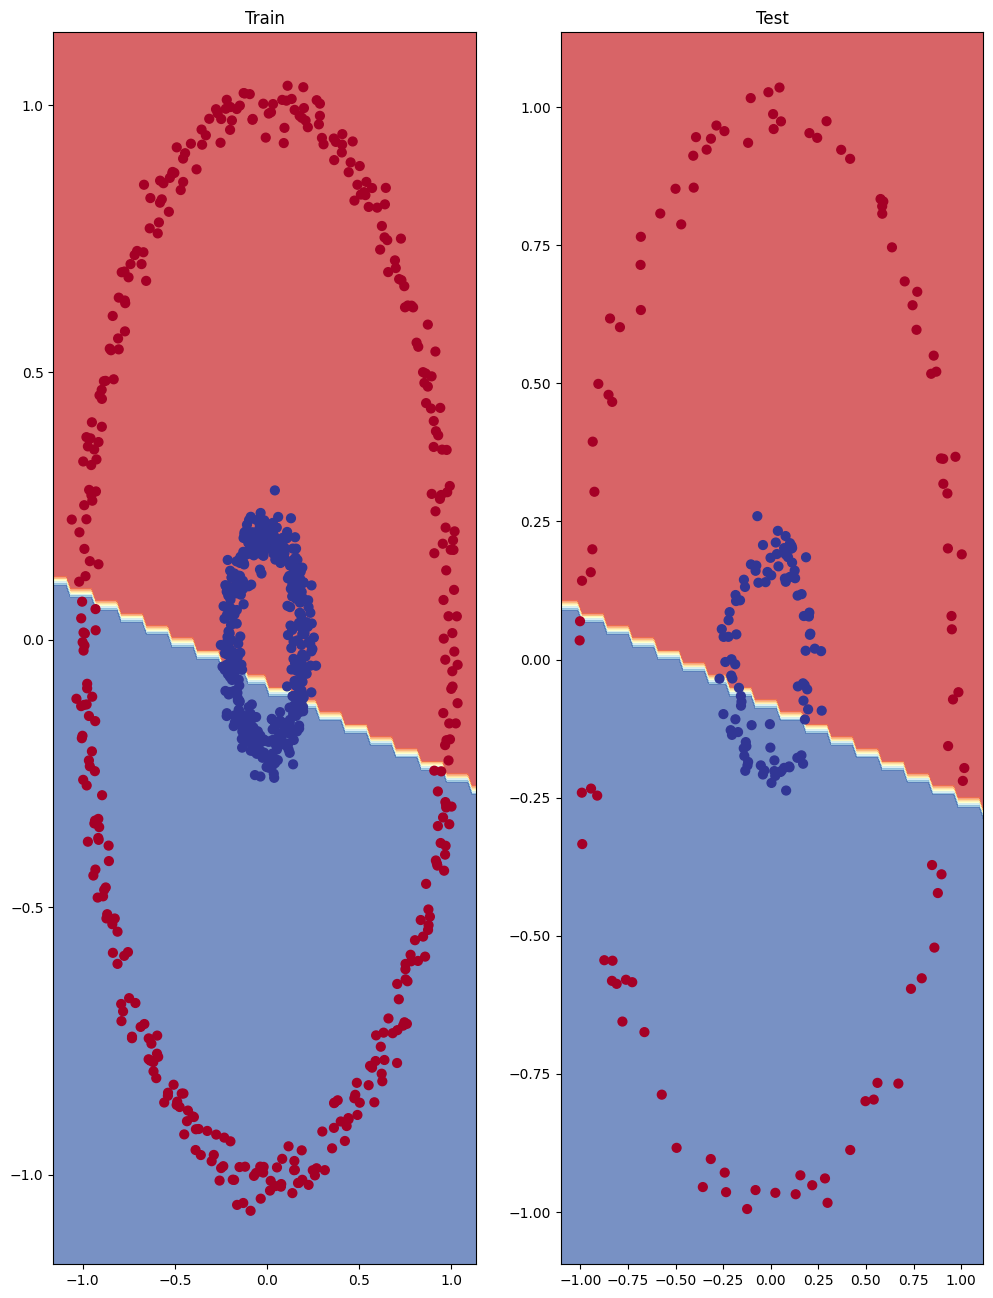

In [26]:
# Plot decision boundary of the model
plt.figure(figsize=(12,16))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)


### Improving a model

In [ ]:
# Add more layers - easier for the model to learn patterns
# Add more hidden units
# Fit for longer
# Change activation functions
# Adjust learning rate
# Change th loss function